In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

In [4]:
file_path = '/content/drive/MyDrive/Car Price Prediction/car_prediction_data.csv'
df = pd.read_csv(file_path)

Delete duplicates

In [5]:
df_clean = df.drop_duplicates().copy()

Feature Derivation

In [6]:
Current_Year = 2026
df_clean["Car_Age"] = Current_Year - df_clean["Year"]

Separate Features (X) and Target (y)

Drop 'Selling_Price' (target), 'Car_Name' (high cardinality), and 'Year' (redundant with Car_Age)

In [7]:
x = df_clean.drop(columns=['Selling_Price', 'Car_Name', 'Year'])
y = df_clean['Selling_Price']

print("Cleaned Dataset Shape:", x.shape)
x.head()

Cleaned Dataset Shape: (299, 7)


,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,5.59,27000,Petrol,Dealer,Manual,0,12
1,9.54,43000,Diesel,Dealer,Manual,0,13
2,9.85,6900,Petrol,Dealer,Manual,0,9
3,4.15,5200,Petrol,Dealer,Manual,0,15
4,6.87,42450,Diesel,Dealer,Manual,0,12


Split into train and test sets

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

Train set shape: (239, 7)
Test set shape: (60, 7)


Build the Preprocessing Transformer

In [10]:
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
numerical_features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# RobustScaler: Uses the median and Interquartile Range (IQR), protecting against extreme outliers in Kms_Driven and Present_Price.

# OneHotEncoder(drop="first"): Turns categories into binary indicators while dropping one category to avoid the dummy variable trap in linear models.

Benchmark All 5 Models Using 5-Fold Cross-Validation

In [16]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

# Define a dictionary of models to be evaluated.
# Each key is the model's name (string) and each value is an instance of the model.
# Hyperparameters are set for some models for demonstration, and n_jobs=1 is used for RandomForest to avoid potential issues in Colab when using multiple cores with TransformedTargetRegressor.
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42, n_jobs=1),
    'Gradient Boosting': GradientBoostingRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Support Vector Machine': SVR(),
    'XGBoost': XGBRegressor(),
    # 'LightGBM': LGBMRegressor(),
    # 'CatBoost': CatBoostRegressor(verbose=0)
}

# Set up K-Fold cross-validation.
# n_splits=5 means the data will be split into 5 folds.
# shuffle=True shuffles the data before splitting, and random_state ensures reproducibility.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Initialize an empty list to store cross-validation results for each model.
cv_records = []

# Loop through each model defined in the 'models' dictionary.
for name, model in models.items():
    # Create a pipeline for each model.
    # The pipeline first applies the preprocessor (scaling numerical features and one-hot encoding categorical features).
    # Then, it passes the preprocessed data to the current model.
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Wrap the pipeline with TransformedTargetRegressor.
    # This applies a log1p transformation (log(1+x)) to the target variable 'y' before training.
    # The inverse_func (expm1, or exp(x)-1) is used to transform predictions back to the original scale.
    # This is often used for skewed target variables like price to make their distribution more normal-like.
    ttr = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    # Perform cross-validation.
    # 'ttr' is the model (pipeline with target transformation).
    # 'x_train' and 'y_train' are the training data and target.
    # 'cv' specifies the K-Fold strategy.
    # 'scoring' defines the metrics to evaluate (Negative Mean Squared Error, Negative Root Mean Squared Error, R-squared).
    # 'return_train_score=True' also calculates scores on the training folds.
    scores = cross_validate(
        ttr,
        x_train,
        y_train,
        cv=cv,
        scoring=['neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2'],
        return_train_score=True
    )

    # Append the averaged cross-validation results for the current model to cv_records.
    # Note that 'neg_mean_squared_error' and 'neg_root_mean_squared_error' are negative by convention in scikit-learn, so we negate them to get actual MSE and RMSE.
    cv_records.append({
        "Model" : name,
        "Train MSE" : -scores['train_neg_mean_squared_error'].mean(),
        "Train RMSE" : -scores['train_neg_root_mean_squared_error'].mean(),
        "Train R2" : scores['train_r2'].mean(),
    })

# Create a Pandas DataFrame from the collected cross-validation records.
# Sort the DataFrame by 'Train R2' in descending order to easily identify the best performing model.
cv_df = pd.DataFrame(cv_records).sort_values(by="Train R2", ascending=False)
# Reset the DataFrame index after sorting, dropping the old index.
cv_df = cv_df.reset_index(drop=True)
# Display the DataFrame containing the cross-validation results.
cv_df

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

,Model,Train MSE,Train RMSE,Train R2
0,XGBoost,0.000197,0.013999,0.999992
1,Gradient Boosting,0.096179,0.309510,0.996059
2,Decision Tree,0.669539,0.814004,0.972749
3,Random Forest,0.700049,0.808830,0.972306
4,K-Nearest Neighbors,1.940201,1.373641,0.922480
5,Support Vector Machine,2.416473,1.502799,0.904968
6,Linear Regression,36.583367,5.720519,-0.426877


In [17]:
# Cell 6: Holdout Test Evaluation
best_model_name = cv_df.iloc[0]["Model"]
print(f"Top Performer from CV: {best_model_name}\n")

# Instantiate and fit the best model
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

final_model = TransformedTargetRegressor(
    regressor=final_pipeline, func=np.log1p, inverse_func=np.expm1
)
final_model.fit(x_train, y_train)

# Evaluate on x_test
y_pred = final_model.predict(x_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"--- Final Evaluation on Unseen Data ({best_model_name}) ---")
print(f"MAE  : {test_mae:.4f} Lakhs")
print(f"RMSE : {test_rmse:.4f} Lakhs")
print(f"R²   : {test_r2:.4f}")
print(f"Min Prediction : {y_pred.min():.2f} (Verified non-negative)")

Top Performer from CV: XGBoost

--- Final Evaluation on Unseen Data (XGBoost) ---
MAE  : 0.8955 Lakhs
RMSE : 1.9362 Lakhs
R²   : 0.8545
Min Prediction : 0.12 (Verified non-negative)


Prediction vs Actual Visual Check

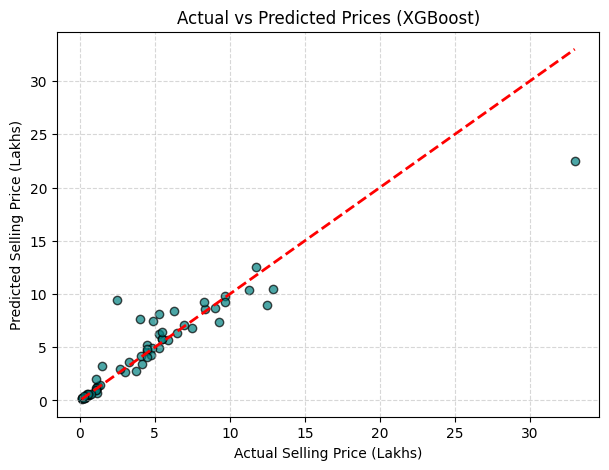

In [18]:
# Cell 7: Inspection Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors="k", color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title(f"Actual vs Predicted Prices ({best_model_name})")
plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Eval on a completely new Car

In [19]:
# Cell 8: Single-Sample Inference
sample_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Kms_Driven": [28000],
    "Car_Age": [4],
    "Owner": [0],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"]
})

predicted_val = final_model.predict(sample_car)
print(f"Estimated Market Value: ₹{predicted_val[0]:.2f} Lakhs")

Estimated Market Value: ₹6.99 Lakhs


## Core Mechanics & Conceptual Breakdown

1.  **Linear Regression**
    *   **How it works:** Fits a straight hyperplane equation:
        $$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$
    *   **Strength:** Fast, highly interpretable; every weight $w_i$ directly describes how a feature shifts price.
    *   **Weakness:** Assumes depreciation is constant. It cannot naturally capture real-world mechanics (e.g., a luxury car losing 40% value in year 1, but leveling off in years 5–10).

2.  **Decision Tree**
    *   **How it works:** Recursively partitions the data by selecting binary thresholds (e.g., Present_Price > 7.5 $\rightarrow$ Car_Age <= 5) that minimize internal variance.
    *   **Strength:** Intuitive; handles non-linear boundaries cleanly.
    *   **Weakness:** High Variance (Unstable). A single deep tree easily overfits and memorizes noise, leading to poor generalization on unseen data.

3.  **Random Forest (Bagging — Bootstrap Aggregation)**
    *   **How it works:** Builds a "forest" of hundreds of independent, unpruned decision trees in parallel. Each tree trains on a random bootstrap sample of rows and considers a random subset of features at each split. The final prediction is the average of all individual trees.
    *   **Strength:** Dramatically lowers the variance of individual decision trees without introducing bias. It rarely overfits on tabular data.
    *   **Weakness:** Cannot extrapolate trends outside the minimum and maximum values seen in training.

4.  **Gradient Boosting Regressor (Boosting — Sequential Correction)**
    *   **How it works:** Instead of training trees independently, trees are trained sequentially. Tree 1 makes a baseline prediction. Tree 2 is trained to predict the residuals (errors) of Tree 1. Tree 3 predicts the errors of Tree 2, scaled down by a learning_rate ($\eta$).
    *   **Strength:** Often achieves lower error than Random Forest because it purposefully attacks the hardest-to-predict samples.
    *   **Weakness:** Sensitive to outliers because it keeps trying to minimize the largest remaining residual errors.

5.  **XGBoost (eXtreme Gradient Boosting)**
    *   **How it works:** An engineered evolution of Gradient Boosting that uses 2nd-order Taylor expansion (both gradients and Hessians) to optimize the loss function.
    *   **Key Enhancements over standard GBM:**
        *   **Regularization:** Built-in $L_1$ (reg_alpha) and $L_2$ (reg_lambda) tree-complexity penalties prevent individual leaves from growing extreme weights.
        *   **Tree Pruning:** Prunes backwards from the bottom using a gamma threshold rather than stopping greedily.
        *   **Performance:** Native parallelization and hardware-level cache optimization.

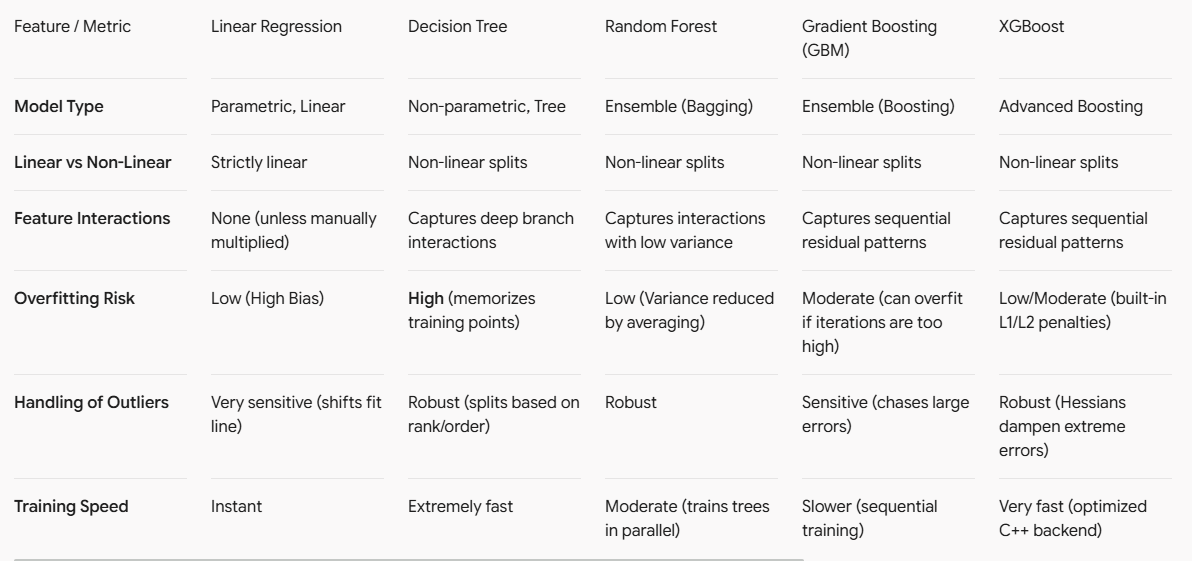